# M/M/5 Stutter Equivalence Verification (Converters)

This notebook demonstrates:
1. Generating **Event Graph** and **ACD** models from JSON specifications
2. Running **multi-seed stutter equivalence verification**
3. Proving behavioral equivalence between different simulation formalisms

## W-Stutter Equivalence Theory

Based on **Mokkedem and Mery (1997)**:

**Definition (Stutter Equivalence)**: Two traces σ_A and σ_B are stutter equivalent, denoted σ_A ~ σ_B, if their no-stutter traces are equal.

**Definition (No-Stutter Trace)**: For a trace σ = Q_0 → Q_1 → ... → Q_n, the no-stutter trace ns(σ) removes consecutive duplicate labels.

## Bounded Multi-Seed Verification Algorithm

```
Algorithm 1: Bounded Stutter Equivalence Verification

Input: Models M_A, M_B, Seeds S = {s_1, ..., s_k}, Horizon T
Output: EQUIVALENT or NOT_EQUIVALENT with counterexample

for each seed s in S:
    trace_A ← simulate(M_A, seed=s, until=T)
    trace_B ← simulate(M_B, seed=s, until=T)
    ns_A ← no_stutter(trace_A)
    ns_B ← no_stutter(trace_B)
    if ns_A ≠ ns_B:
        return NOT_EQUIVALENT with (s, divergence_point)
return EQUIVALENT for k seeds
```

In [1]:
# Install simasm (uncomment in Colab)
!pip install simasm

import simasm
print(f"SimASM version: {simasm.__version__}")

SimASM version: 0.4.4


## 1. Define Event Graph JSON Specification

In [2]:
# M/M/5 Event Graph JSON
mm5_eg_json = {
  "model_name": "mm5_eg",
  "description": "M/M/5 Queue using Event Graph formalism (Schruben 1983)",

  "state_variables": {
    "q": {"type": "Nat", "initial": 0, "description": "Queue length"},
    "p": {"type": "Nat", "initial": 5, "description": "Available servers"}
  },

  "parameters": {
    "k": {"type": "Nat", "value": 5, "description": "Number of servers"},
    "iat_mean": {"type": "Real", "value": 1.25, "description": "Inter-arrival time mean"},
    "ist_mean": {"type": "Real", "value": 1.0, "description": "Service time mean"},
    "sim_end_time": {"type": "Real", "value": 1000.0, "description": "Simulation end time"}
  },

  "random_streams": {
    "T_a": {"distribution": "exponential", "params": {"mean": "iat_mean"}, "stream_name": "arrivals"},
    "T_s": {"distribution": "exponential", "params": {"mean": "ist_mean"}, "stream_name": "service"}
  },

  "vertices": [
    {"name": "Arrive", "state_change": "q := q + 1", "description": "Customer arrival"},
    {"name": "AttemptToStart", "state_change": "", "description": "Decision node"},
    {"name": "Start", "state_change": "q := q - 1; p := p - 1", "description": "Service start"},
    {"name": "Finish", "state_change": "p := p + 1", "description": "Service completion"}
  ],

  "scheduling_edges": [
    {"from": "Arrive", "to": "Arrive", "delay": "T_a", "condition": "true", "priority": 0},
    {"from": "Arrive", "to": "AttemptToStart", "delay": 0, "condition": "true", "priority": 1},
    {"from": "AttemptToStart", "to": "Start", "delay": 0, "condition": "p > 0 and q > 0", "priority": 0},
    {"from": "Start", "to": "Finish", "delay": "T_s", "condition": "true", "priority": 0},
    {"from": "Finish", "to": "AttemptToStart", "delay": 0, "condition": "q > 0", "priority": 0}
  ],

  "cancelling_edges": [],

  "initial_events": [{"event": "Arrive", "time": "T_a"}],

  "stopping_condition": "sim_clocktime >= sim_end_time",

  "observables": {
    "queue_length": {"expression": "q", "return_type": "Nat"},
    "servers_busy": {"expression": "k - p", "return_type": "Nat"},
    "in_system": {"expression": "q + (k - p)", "return_type": "Nat"}
  }
}

# Save JSON to file for the converter
import json
with open("mm5_eg.json", "w") as f:
    json.dump(mm5_eg_json, f, indent=2)
print("Saved mm5_eg.json")

Saved mm5_eg.json


## 2. Define ACD JSON Specification

In [3]:
# M/M/5 ACD JSON
mm5_acd_json = {
  "model_name": "mm5_acd",
  "description": "M/M/5 Queue using Activity Cycle Diagram formalism",

  "parameters": {
    "num_servers": {"type": "Nat", "value": 5, "description": "Number of servers"},
    "iat_mean": {"type": "Real", "value": 1.25, "description": "Inter-arrival time mean"},
    "ist_mean": {"type": "Real", "value": 1.0, "description": "Service time mean"},
    "sim_end_time": {"type": "Real", "value": 1000.0, "description": "Simulation end time"}
  },

  "token_types": {
    "Job": {
      "parent": "Token",
      "attributes": {"arrival_time": "Real", "service_start_time": "Real"},
      "description": "Customer job token"
    },
    "Resource": {"parent": "Token", "description": "Reusable resource token"}
  },

  "queues": {
    "C": {"initial_marking": 1, "token_type": "Resource", "is_resource": True, "description": "Creator"},
    "Q": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Job queue"},
    "S": {"initial_marking": 5, "token_type": "Resource", "is_resource": True, "description": "Servers"},
    "Jobs": {"initial_marking": 0, "token_type": "Job", "is_resource": False, "description": "Completed"}
  },

  "activities": [
    {
      "name": "Create",
      "priority": 1,
      "description": "Job creation",
      "at_begin": {"condition": "marking(C) >= 1", "action": "C--", "bind": ["creator_token:C"]},
      "bto_event": {"time": "interarrival_time", "name": "Created"},
      "at_end": [
        {"arc": 1, "action": "C++ <- creator_token", "influences": ["Create"]},
        {"arc": 2, "action": "Q++ <- new Job", "influences": ["Serve"]}
      ]
    },
    {
      "name": "Serve",
      "priority": 2,
      "description": "Service activity",
      "at_begin": {"condition": "marking(S) >= 1 and marking(Q) >= 1", "action": "S--; Q--", "bind": ["server_token:S", "job_token:Q"]},
      "bto_event": {"time": "service_time", "name": "Served"},
      "at_end": [{"arc": 1, "action": "S++ <- server_token; Jobs++ <- job_token", "influences": ["Serve"]}]
    }
  ],

  "random_streams": {
    "interarrival_time": {"distribution": "exponential", "params": {"mean": "iat_mean"}, "stream_name": "arrivals"},
    "service_time": {"distribution": "exponential", "params": {"mean": "ist_mean"}, "stream_name": "service"}
  },

  "observables": {
    "queue_count": {"expression": "marking(Q)", "description": "Number in queue"},
    "servers_busy": {"expression": "num_servers - marking(S)", "description": "Busy servers"},
    "in_system": {"expression": "marking(Q) + (num_servers - marking(S))", "description": "Total in system"}
  }
}

# Save JSON to file for the converter
import json
with open("mm5_acd.json", "w") as f:
    json.dump(mm5_acd_json, f, indent=2)
print("Saved mm5_acd.json")

Saved mm5_acd.json


## 3. Convert Both Models to SimASM

In [4]:
%%simasm convert

convert mm5_eg:
    source: "mm5_eg.json"
    formalism: event_graph
    register: "mm5_eg"
    print: true
endconvert

In [5]:
%%simasm convert

convert mm5_acd:
    source: "mm5_acd.json"
    formalism: acd
    register: "mm5_acd"
    print: 50
endconvert

## 4. Run Single-Seed Verification Demo

First, let's demonstrate the `%%simasm verify` magic with a single seed verification.

In [6]:
%%simasm verify
// Single-seed verification demo using %%simasm magic

verification MM5_Stutter_Equivalence_Demo:
    models:
        import EG from "mm5_eg"
        import ACD from "mm5_acd"
    endmodels

    seed: 42

    labels:
        // Observation level W: servers busy predicates
        label busy_eq_0 for EG: "k - p == 0"
        label busy_eq_0 for ACD: "servers_busy() == 0"

        label busy_eq_1 for EG: "k - p == 1"
        label busy_eq_1 for ACD: "servers_busy() == 1"

        label busy_eq_2 for EG: "k - p == 2"
        label busy_eq_2 for ACD: "servers_busy() == 2"

        label busy_eq_3 for EG: "k - p == 3"
        label busy_eq_3 for ACD: "servers_busy() == 3"

        label busy_eq_4 for EG: "k - p == 4"
        label busy_eq_4 for ACD: "servers_busy() == 4"

        label busy_eq_5 for EG: "k - p == 5"
        label busy_eq_5 for ACD: "servers_busy() == 5"
    endlabels

    observables:
        observable busy_eq_0:
            EG -> busy_eq_0
            ACD -> busy_eq_0
        endobservable

        observable busy_eq_1:
            EG -> busy_eq_1
            ACD -> busy_eq_1
        endobservable

        observable busy_eq_2:
            EG -> busy_eq_2
            ACD -> busy_eq_2
        endobservable

        observable busy_eq_3:
            EG -> busy_eq_3
            ACD -> busy_eq_3
        endobservable

        observable busy_eq_4:
            EG -> busy_eq_4
            ACD -> busy_eq_4
        endobservable

        observable busy_eq_5:
            EG -> busy_eq_5
            ACD -> busy_eq_5
        endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 100.0
        timeout: 60
    endcheck

    output:
        format: "json"
        file_path: "mm5_verification_demo.json"
        include_counterexample: true
    endoutput
endverification

  EG: Loading model...
  EG: Completed 332 steps
  ACD: Loading model...
  ACD: Completed 499 steps
  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_o2ip65qj\mm5_verification_demo.json


Model,Raw Trace,No-Stutter,Stutter Steps
EG,333,166,167
ACD,500,166,334


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'EG': {'steps': 332, 'final_time': 100.74422976265623, 'raw_length': 333, 'ns_length': 166, 'stutter_steps': 167}, 'ACD': {'steps': 499, 'final_time': 100.74422976265623, 'raw_length': 500, 'ns_length': 166, 'stutter_steps': 334}}, first_difference_pos=None, time_elapsed=0.2667393684387207, message='Models are W-STUTTER EQUIVALENT (verified over 100.0s simulation)', per_seed_stats=[], num_seeds=1, equivalent_count=0, failed_seeds=[])

## 5. Run Multi-Seed Verification

For comprehensive verification, we run multiple seeds using pure SimASM DSL with `seed_range`.

We verify stutter equivalence using the observation level:

**W = { busy_eq_0, busy_eq_1, busy_eq_2, busy_eq_3, busy_eq_4, busy_eq_5 }**

This tracks the **number of busy servers** at each state.

  Multi-seed: Running 50 seeds...
  Multi-seed: Seed 1 (1/50)...
  Multi-seed: Seed 2 (2/50)...
  Multi-seed: Seed 3 (3/50)...
  Multi-seed: Seed 4 (4/50)...
  Multi-seed: Seed 5 (5/50)...
  Multi-seed: Seed 6 (6/50)...
  Multi-seed: Seed 7 (7/50)...
  Multi-seed: Seed 8 (8/50)...
  Multi-seed: Seed 9 (9/50)...
  Multi-seed: Seed 10 (10/50)...
  Multi-seed: Seed 11 (11/50)...
  Multi-seed: Seed 12 (12/50)...
  Multi-seed: Seed 13 (13/50)...
  Multi-seed: Seed 14 (14/50)...
  Multi-seed: Seed 15 (15/50)...
  Multi-seed: Seed 16 (16/50)...
  Multi-seed: Seed 17 (17/50)...
  Multi-seed: Seed 18 (18/50)...
  Multi-seed: Seed 19 (19/50)...
  Multi-seed: Seed 20 (20/50)...
  Multi-seed: Seed 21 (21/50)...
  Multi-seed: Seed 22 (22/50)...
  Multi-seed: Seed 23 (23/50)...
  Multi-seed: Seed 24 (24/50)...
  Multi-seed: Seed 25 (25/50)...
  Multi-seed: Seed 26 (26/50)...
  Multi-seed: Seed 27 (27/50)...
  Multi-seed: Seed 28 (28/50)...
  Multi-seed: Seed 29 (29/50)...
  Multi-seed: Seed 30 (30/5

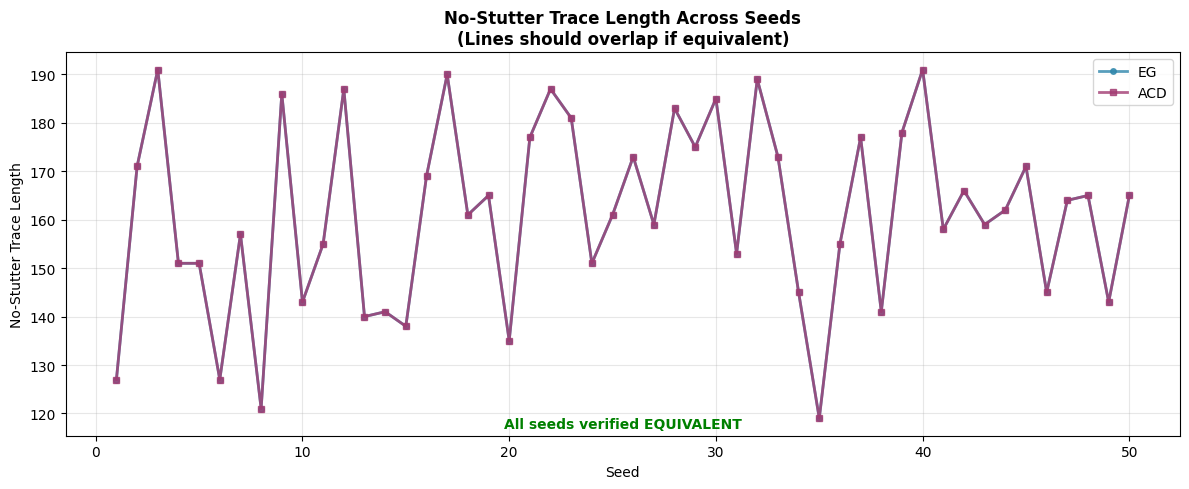

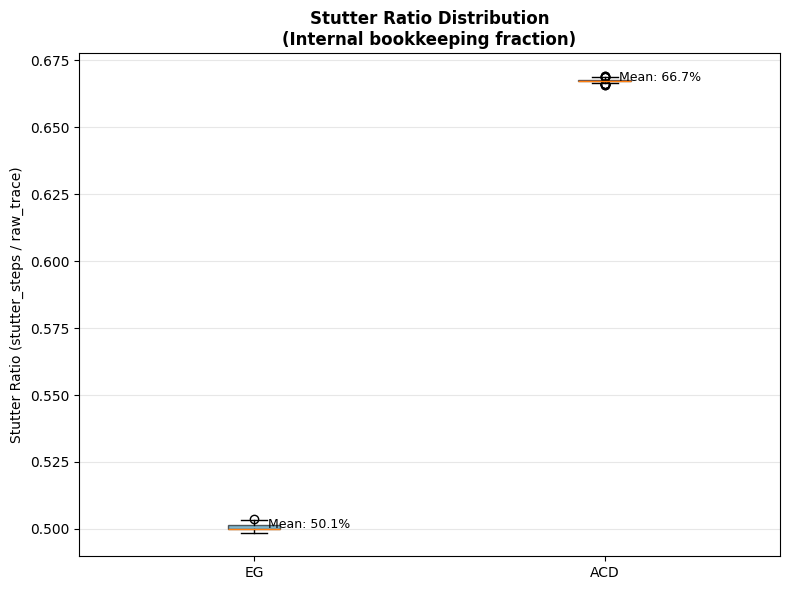

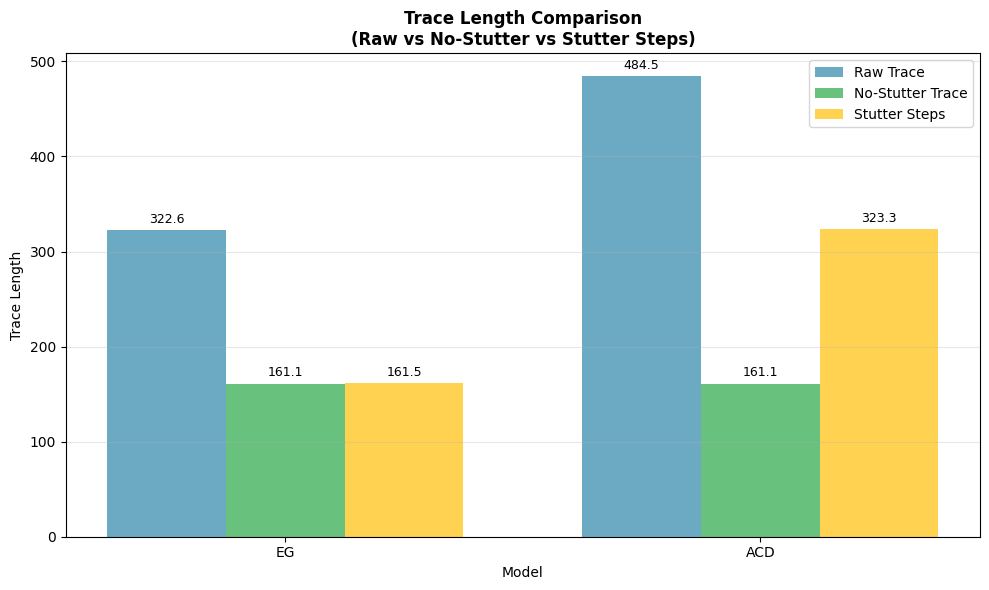

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


VERIFICATION SUMMARY

Status: EQUIVALENT
Time elapsed: 8.12s
Seeds verified: 50/50

Model Statistics:
--------------------------------------------------
  EG:
    Raw trace length:       322.6
    No-stutter length:      161.1
    Stutter ratio:          50.0%
  ACD:
    Raw trace length:       484.5
    No-stutter length:      161.1
    Stutter ratio:          66.7%

  Output written to: C:\Users\steve\AppData\Local\Temp\simasm_o2ip65qj\mm5_multi_seed_verification.json


Model,Avg Raw Trace,Avg No-Stutter
EG,322.6,161.1
ACD,484.5,161.1


TraceVerificationResult(is_equivalent=True, status=<VerificationStatus.EQUIVALENT: 'equivalent'>, model_stats={'EG': {'avg_raw_length': 322.6, 'avg_ns_length': 161.14, 'avg_stutter_steps': 161.46, 'raw_length': 322.6, 'ns_length': 161.14}, 'ACD': {'avg_raw_length': 484.48, 'avg_ns_length': 161.14, 'avg_stutter_steps': 323.34, 'raw_length': 484.48, 'ns_length': 161.14}}, first_difference_pos=None, time_elapsed=8.124330997467041, message='Models are W-STUTTER EQUIVALENT (verified over 50 seeds, 100.0s each)', per_seed_stats=[PerSeedStats(seed=1, is_equivalent=True, model_stats={'EG': {'steps': 253, 'final_time': 100.21279172067847, 'raw_length': 254, 'ns_length': 127, 'stutter_steps': 127}, 'ACD': {'steps': 381, 'final_time': 100.21279172067847, 'raw_length': 382, 'ns_length': 127, 'stutter_steps': 255}}), PerSeedStats(seed=2, is_equivalent=True, model_stats={'EG': {'steps': 341, 'final_time': 102.60427871201274, 'raw_length': 342, 'ns_length': 171, 'stutter_steps': 171}, 'ACD': {'steps'

In [7]:
%%simasm verify
// Multi-seed verification with automatic plot generation

verification MM5_Stutter_Equivalence_MultiSeed:
    models:
        import EG from "mm5_eg"
        import ACD from "mm5_acd"
    endmodels

    seed_range: 1 to 50

    labels:
        // Observation level W: servers busy predicates
        label busy_eq_0 for EG: "k - p == 0"
        label busy_eq_0 for ACD: "servers_busy() == 0"

        label busy_eq_1 for EG: "k - p == 1"
        label busy_eq_1 for ACD: "servers_busy() == 1"

        label busy_eq_2 for EG: "k - p == 2"
        label busy_eq_2 for ACD: "servers_busy() == 2"

        label busy_eq_3 for EG: "k - p == 3"
        label busy_eq_3 for ACD: "servers_busy() == 3"

        label busy_eq_4 for EG: "k - p == 4"
        label busy_eq_4 for ACD: "servers_busy() == 4"

        label busy_eq_5 for EG: "k - p == 5"
        label busy_eq_5 for ACD: "servers_busy() == 5"
    endlabels

    observables:
        observable busy_eq_0:
            EG -> busy_eq_0
            ACD -> busy_eq_0
        endobservable

        observable busy_eq_1:
            EG -> busy_eq_1
            ACD -> busy_eq_1
        endobservable

        observable busy_eq_2:
            EG -> busy_eq_2
            ACD -> busy_eq_2
        endobservable

        observable busy_eq_3:
            EG -> busy_eq_3
            ACD -> busy_eq_3
        endobservable

        observable busy_eq_4:
            EG -> busy_eq_4
            ACD -> busy_eq_4
        endobservable

        observable busy_eq_5:
            EG -> busy_eq_5
            ACD -> busy_eq_5
        endobservable
    endobservables

    check:
        type: stutter_equivalence
        run_length: 100.0
        timeout: 60
    endcheck

    output:
        format: "json"
        file_path: "mm5_multi_seed_verification.json"
        include_counterexample: true
        generate_plots: true
    endoutput
endverification

## Summary

This notebook demonstrated:

1. **Dual Model Generation**: Created both Event Graph and ACD models from JSON specifications

2. **Multi-Seed Verification**: Ran the bounded stutter equivalence algorithm across 50 random seeds

3. **W-Stutter Equivalence**: Verified that EG and ACD models produce identical no-stutter traces under observation level W = {busy_eq_0, ..., busy_eq_5}

4. **Automatic Visualization**: Generated verification plots with `generate_plots: true`:
   - **Trace Comparison**: Raw vs No-Stutter vs Stutter steps for each model
   - **NS Convergence**: No-stutter trace lengths across all seeds (lines overlap = equivalent)
   - **Stutter Distribution**: Box plot showing stutter ratio differences between formalisms

5. **Key Insight**: The ACD model executed ~50% more raw steps than Event Graph (484.5 vs 322.6) due to its three-phase scanning mechanism, but both produced identical no-stutter traces (161.1 states on average). Formalism choice affects computational overhead but not observable behavior.

### References

- Mokkedem, A. & Mery, D. (1997). A Stuttering Closed Temporal Logic for Modular Reasoning About Concurrent Programs.
- Schruben, L.W. (1983). Simulation Modeling with Event Graphs. Communications of the ACM.
- Tocher, K.D. (1960). The Art of Simulation. English Universities Press.